## Ejercicio 15

Consideremos un problema similar al Ejercicio 5. Nos interesa estudiar la dinámica de una pelota que cae en caída libre y rebota cuando llega al suelo. En principio, supondremos que el rebote no implica pérdida de energía y que la caída es sin rozamiento, por lo cual:

$$
\ddot{x} = -\frac{g}{m}.
$$

**(a)** Detectar cuando la pelota toca el suelo y realizar la corrección correspondiente, poniendo $x=-x$ y $v=-v$. Resolver el problema con este enfoque para un tiempo suficientemente largo como para ver cuatro o cinco rebotes.

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 

In [3]:
def sistema(t, estado, masa, g=9.81):
    x, v = estado
    dXdt = v
    dVdt = -g / masa
    return np.array([dXdt, dVdt])

def euler(x0, v0, masa, t0, tf, h):
    # Número de pasos 
    num_pasos = int((tf-t0) / h)
    t = np.linspace(t0, tf, num_pasos + 1)
    
    # Soluciones 
    X = np.zeros(num_pasos+1)
    V = np.zeros(num_pasos + 1)

    # Condiciones iniciales
    X[0] = x0
    V[0] = v0

    for n in range(num_pasos):
        tn = t[n]

        estado = np.array([X[n], V[n]])
        dX, dV = sistema(tn, estado, masa)

        X[n+1] = X[n] + h * dX
        V[n+1] = V[n] + h * dV

        if X[n+1] < 0:
            X[n+1] = -X[n+1]
            V[n+1] = -V[n+1]

    return t, X, V

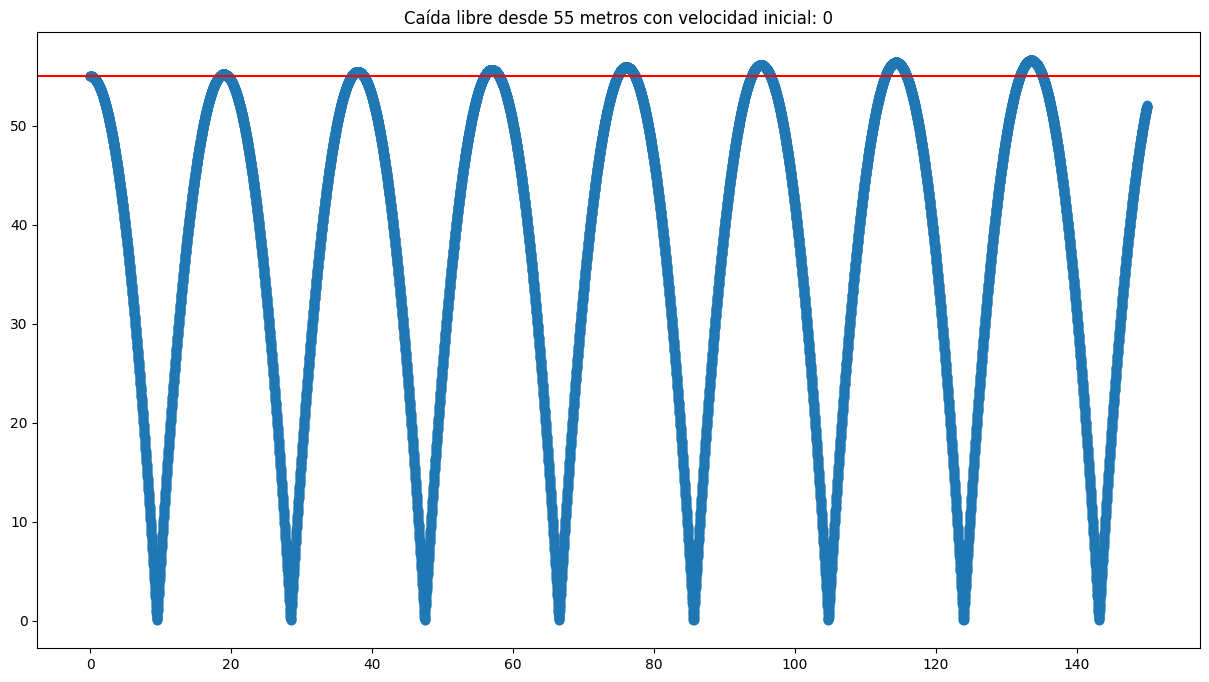

In [14]:
tiempo, posicion, velocidad = euler(55, 0, 8, 0, 150, 0.01)

plt.figure(figsize=(15,8))
plt.axhline(55, color='red')
plt.scatter(tiempo, posicion)
plt.title(f'Caída libre desde {posicion[0]:.0f} metros con velocidad inicial: {velocidad[0]:.0f}')
plt.show()

**(b)** Repetir las simulaciones anteriores pero asumiendo rozamiento con el aire y/o una pérdida de energía en el choque (es decir: la velocidad post-choque es una fracción de la velocidad pre-choque).